In [1]:
import numpy as np
import pandas as pd

In [2]:
# Read file
df = pd.read_csv("dataset/backtest_df.csv")
df['period'] = pd.to_datetime(df['period'])
df = df.sort_values('period').reset_index(drop=True)

df

,period,true_usd,pred_usd,realized_return,cond_vol
0,2023-02-14,15292.08,15236.577,0.005007,0.003585
1,2023-02-15,15243.84,15286.437,0.003160,0.003598
2,2023-02-16,15269.97,15297.227,0.001713,0.003611
3,2023-02-17,15251.88,15297.050,0.001185,0.003624
4,2023-02-20,15275.00,15285.442,0.001515,0.003637
...,...,...,...,...,...
442,2024-12-23,16351.35,16335.102,0.000430,0.004207
443,2024-12-24,16239.80,16409.945,0.006845,0.004207
444,2024-12-27,16289.04,16325.783,0.003027,0.004207
445,2024-12-30,16332.25,16284.535,0.002649,0.004207


## Backtesting Trading Simulation
This code enables **end-to-end backtesting** by linking model predictions to simulated trading outcomes, allowing comparison of active GARCH-LSTM strategies versus a passive Buy & Hold approach. Here are the steps:

1. **Return Calculation**  
   - Compute percentage returns for both predicted (`pred_usd`) and actual (`true_usd`) prices.  
   - These returns serve as signals for generating buy/sell decisions.

2. **Strategy Configuration**  
   - Define multiple trading configurations with maximum holding days and take-profit levels.  
   - Each configuration simulates different risk/reward preferences.

3. **Simulation Function (`simulate_strategy`)**  
   - Iterates over each day in the dataset.  
   - Generates **buy signals** when predicted returns are positive and no position is held.  
   - Holds positions until either take-profit is reached or maximum holding days expire.  
   - Updates **equity curve** daily to track portfolio value.  
   - Tracks indices of buy/sell events for visualization or analysis.

4. **Run Simulation for All Configurations**  
   - Stores equity curves and trading signals for each configuration.  
   - Also computes a **Buy & Hold baseline** for comparison.

5. **Performance Metrics (`performance_metrics`)**  
   - Calculates total return, annualized return, Sharpe ratio, and maximum drawdown.  
   - Provides a quantitative evaluation of each strategy.

6. **Visualization**  
   - Plots equity curves for all strategies on the same chart.  
   - Buy & Hold is shown as a solid line; GARCH-LSTM strategies are dashed.  
   - Y-axis formatted to currency (Rp) for clarity.


Configuration 1 (5D - 2.5%) Strategy:
Total Return (%): 6.31
Annualized Return (%): 3.51
Sharpe Ratio: 0.75
Max Drawdown (%): -5.23

Configuration 2 (10D - 4%) Strategy:
Total Return (%): 7.92
Annualized Return (%): 4.39
Sharpe Ratio: 0.87
Max Drawdown (%): -5.30

Configuration 3 (30D - 6%) Strategy:
Total Return (%): 8.19
Annualized Return (%): 4.54
Sharpe Ratio: 0.81
Max Drawdown (%): -7.89

Buy & Hold Strategy:
Total Return (%): 6.22
Annualized Return (%): 3.46
Sharpe Ratio: 0.61
Max Drawdown (%): -8.30


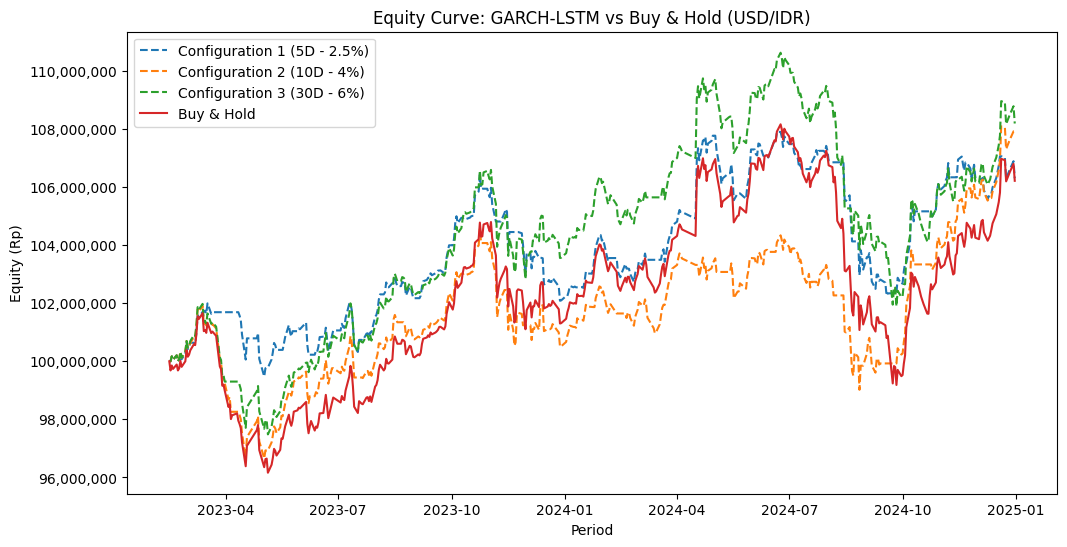

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Hitung returns
df['pred_return'] = df['pred_usd'].pct_change().fillna(0)
df['true_return'] = df['true_usd'].pct_change().fillna(0)

# Initial modal
initial_capital = 100_000_000

# Konfigurasi strategi
configs = [
    {"name": "Configuration 1 (5D - 2.5%)", "max_holding_days": 5, "take_profit": 0.025},
    {"name": "Configuration 2 (10D - 4%)", "max_holding_days": 10,  "take_profit": 0.04},
    {"name": "Configuration 3 (30D - 6%)", "max_holding_days": 30, "take_profit": 0.06},
]

# Simulasi strategi
def simulate_strategy(df, max_holding_days, take_profit):
    capital = initial_capital
    position = 0
    entry_price = 0
    holding_days = 0
    equity_curve = []
    buy_idx = []
    sell_idx = []

    for i in range(len(df)):
        current_price = df.loc[i, 'true_usd']
        current_pred_return = df.loc[i, 'pred_return']

        # Buy signal
        if current_pred_return > 0 and position == 0:
            position = 1
            entry_price = current_price
            holding_days = 1
            buy_idx.append(i)

        # Hold position
        elif position == 1:
            holding_days += 1
            cumulative_return = (current_price / entry_price) - 1

            # Sell conditions
            if cumulative_return >= take_profit or holding_days > max_holding_days:
                capital *= (1 + cumulative_return)
                position = 0
                entry_price = 0
                holding_days = 0
                cumulative_return = 0
                sell_idx.append(i)

        # Update equity curve
        if position == 1:
            equity_curve.append(capital * (1 + (current_price / entry_price - 1)))
        else:
            equity_curve.append(capital)

    return pd.Series(equity_curve, index=df['period']), buy_idx, sell_idx

# Simulasikan semua konfigurasi
equity_curves = {}
signals = {}

for cfg in configs:
    eq, buy_idx, sell_idx = simulate_strategy(df, cfg["max_holding_days"], cfg["take_profit"])
    equity_curves[cfg["name"]] = eq
    signals[cfg["name"]] = {"buy": buy_idx, "sell": sell_idx}

# Buy & Hold (Baseline)
buy_hold_equity = initial_capital * (1 + df['true_return']).cumprod()
equity_curves["Buy & Hold"] = buy_hold_equity

# Metrics
def performance_metrics(equity, label):
    equity = np.array(equity)
    equity = np.nan_to_num(equity, nan=initial_capital, posinf=initial_capital, neginf=initial_capital)
    equity = np.where(equity <= 0, initial_capital, equity)

    returns = np.diff(equity) / np.where(equity[:-1] != 0, equity[:-1], 1)
    returns = np.nan_to_num(returns)

    total_return = (equity[-1] - initial_capital) / initial_capital * 100
    annualized_return = ((equity[-1] / initial_capital) ** (252/len(equity)) - 1) * 100

    sharpe_ratio = 0
    if np.std(returns) != 0:
        sharpe_ratio = np.mean(returns) / np.std(returns) * np.sqrt(252)

    running_max = np.maximum.accumulate(equity)
    max_drawdown = ((equity - running_max) / running_max).min() * 100

    print(f"\n{label} Strategy:")
    print(f"Total Return (%): {total_return:.2f}")
    print(f"Annualized Return (%): {annualized_return:.2f}")
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Max Drawdown (%): {max_drawdown:.2f}")
    return total_return, annualized_return, sharpe_ratio, max_drawdown

# Print metrics
for name, eq in equity_curves.items():
    performance_metrics(eq, name)

# Plot Equity Curves
df['period'] = pd.to_datetime(df['period'])
df = df.sort_values('period').reset_index(drop=True)

plt.figure(figsize=(12,6))
for name, eq in equity_curves.items():
    linestyle = '--' if name != "Buy & Hold" else '-'
    plt.plot(df['period'], eq.values, label=name, linestyle=linestyle)

plt.xlabel('Period')
plt.ylabel('Equity (Rp)')
plt.title('Equity Curve: GARCH-LSTM vs Buy & Hold (USD/IDR)')
plt.legend()
# Hilangkan notasi ilmiah di sumbu Y
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

### Key Takeaways from Backtesting Results

1. **GARCH-LSTM Improves Profitability**
   - All configurations outperform Buy & Hold in total and annualized returns.
   - Using historical price patterns + GARCH volatility allows the model to capture short-term opportunities, making active trading more profitable than passive holding.

2. **Better Risk-Adjusted Performance**
   - Sharpe ratios (0.75–0.87) are higher than Buy & Hold (0.61), showing improved returns relative to risk.
   - Short and medium holding periods (5–10D) balance profit and volatility, limiting losses during extreme market moves.

3. **Drawdown and Holding Period Insights**
   - Maximum drawdowns are generally lower than Buy & Hold, except for the longest holding period (30D) where exposure increases risk.
   - Moderate holding periods (10D / 4%) achieve the best trade-off between return, risk, and drawdown.

**Conclusion:**
Predicted returns from GARCH-LSTM combined with volatility-informed signals make the trading strategy more responsive and risk-conscious than Buy & Hold, especially with moderate holding periods.

## Plot Price + Buy/Sell Signals per Config

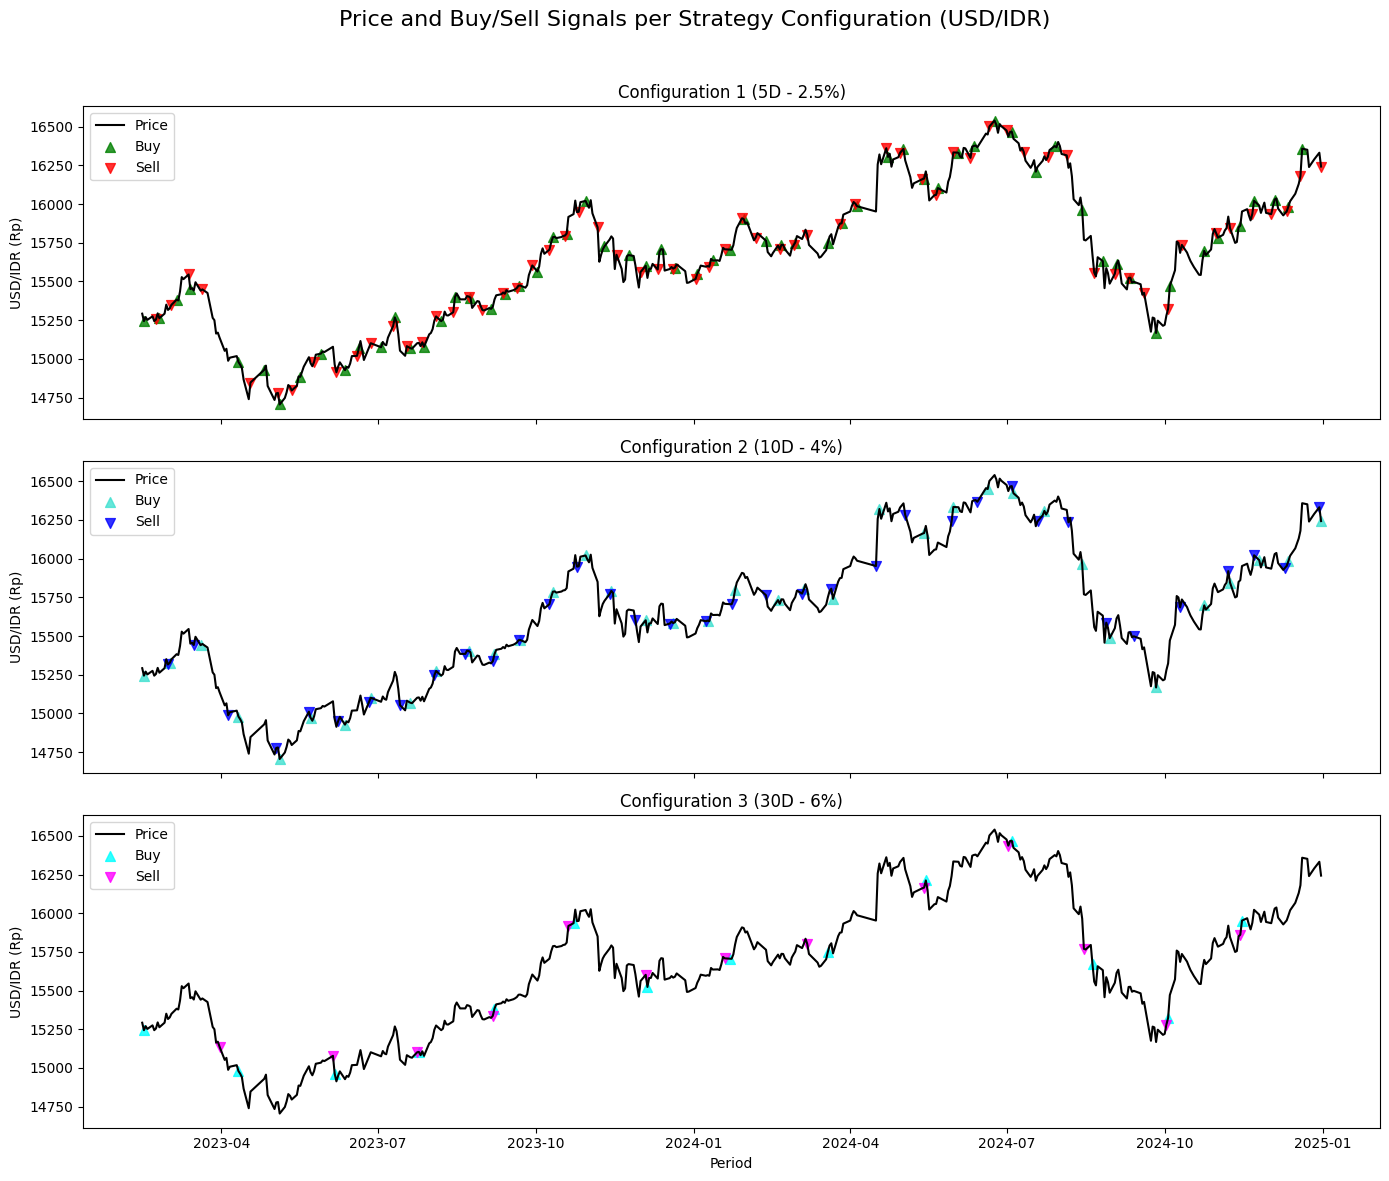

In [5]:
fig, axes = plt.subplots(len(configs), 1, figsize=(14, 12), sharex=True)

colors_buy = ['green', 'turquoise', 'cyan']
colors_sell = ['red', 'blue', 'magenta']

for i, cfg in enumerate(configs):
    axes[i].plot(df['period'], df['true_usd'], color='black', label='Price')
    axes[i].scatter(df['period'].iloc[signals[cfg["name"]]["buy"]],
                    df['true_usd'].iloc[signals[cfg["name"]]["buy"]],
                    marker='^', s=50, color=colors_buy[i], label='Buy', alpha=0.8)
    axes[i].scatter(df['period'].iloc[signals[cfg["name"]]["sell"]],
                    df['true_usd'].iloc[signals[cfg["name"]]["sell"]],
                    marker='v', s=50, color=colors_sell[i], label='Sell', alpha=0.8)
    axes[i].set_ylabel('USD/IDR (Rp)')
    axes[i].set_title(cfg["name"])
    axes[i].legend(loc='upper left')

plt.xlabel('Period')
plt.suptitle('Price and Buy/Sell Signals per Strategy Configuration (USD/IDR)', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

## Sell Signal Interpretation:

Configuration 1 (5D–2.5%) – Frequent sell signals; closes positions quickly to capture small short-term gains but risks over-trading during volatile periods.

Configuration 2 (10D–4%) – Moderate frequency; balances responsiveness with noise reduction, allowing exits on meaningful mid-term price movements.

Configuration 3 (30D–6%) – Infrequent sell signals; only triggers on significant reversals, filtering out short-term fluctuations and capturing long-term trends.